# Análisis exploratorio de datos

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Usuario\miniconda3\envs\env_logistica_py313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Definición del problema

> Análisis del impacto de factores externos como el tráfico y el clima en los plazos de entrega.
> - ¿Cuál es el factor principal que genera la desviación en los tiempos de entrega? 
> -  ¿Podemos predecir y evitar que un envio se retrase?

>  ¿Cuál es el factor principal que genera la desviación en los tiempos de entrega? 
> - Seguimiento de (ETA Variation)

>  ¿Podemos predecir y evitar que un envio se retrase?
> - Seguimiento de (Delay Probability)


## Recopilación de Datos

In [2]:
# Download latest version
path = kagglehub.dataset_download("datasetengineer/logistics-and-supply-chain-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\datasetengineer\logistics-and-supply-chain-dataset\versions\1


In [3]:
df = pd.read_csv("../data/raw/dynamic_supply_chain_logistics_dataset.csv") 

## Análisis Descriptivo

In [4]:
df

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32060,2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.992997,...,-8.835069,0.199377,9.893402,0.966050,0.109571,0.511074,0.953467,0.916745,High Risk,5.506049
32061,2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.946031,...,-2.517654,0.673775,0.854378,1.665889,0.530289,0.868418,0.995329,0.808963,High Risk,-1.876938
32062,2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.437687,...,29.410878,0.949644,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,Moderate Risk,9.790219
32063,2024-08-28 23:00:00,32.082410,-70.070154,5.000000,4.759411,0.932050,972.437425,0.505242,0.250949,0.517051,...,-6.951137,0.407377,9.185549,4.462204,0.012896,0.463018,0.999999,0.557340,High Risk,9.956879


In [5]:
df.columns

Index(['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'warehouse_inventory_level',
       'loading_unloading_time', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'port_congestion_level', 'shipping_costs', 'supplier_reliability_score',
       'lead_time_days', 'historical_demand', 'iot_temperature',
       'cargo_condition_status', 'route_risk_level', 'customs_clearance_time',
       'driver_behavior_score', 'fatigue_monitoring_score',
       'disruption_likelihood_score', 'delay_probability',
       'risk_classification', 'delivery_time_deviation'],
      dtype='str')

In [6]:
# información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  str    
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs               

In [7]:
# 2. Revisión de valores nulos (fundamental para limpieza)
df.isnull().sum()

timestamp                          0
vehicle_gps_latitude               0
vehicle_gps_longitude              0
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unloading_time             0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
port_congestion_level              0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
iot_temperature                    0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
driver_behavior_score              0
fatigue_monitoring_score           0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
dtype: int64

In [8]:
# Primer vistazo a las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_gps_latitude,32065.0,38.023589,6.917909,3.000000e+01,31.280550,36.413820,44.453655,50.000000
vehicle_gps_longitude,32065.0,-90.116648,17.369244,-1.200000e+02,-106.253913,-86.293414,-73.079367,-70.000000
fuel_consumption_rate,32065.0,8.011735,4.264960,5.000000e+00,5.019984,5.636036,9.669944,19.999875
eta_variation_hours,32065.0,2.893068,2.274044,-1.999993e+00,1.185744,3.882059,4.884355,5.000000
traffic_congestion_level,32065.0,4.991493,3.532048,1.091633e-09,1.474720,4.981244,8.534902,9.999999
warehouse_inventory_level,32065.0,299.254732,323.443513,1.322210e-12,16.051635,157.288022,540.597991,999.999298
loading_unloading_time,32065.0,2.291669,1.554202,5.000000e-01,0.774798,1.917121,3.734188,5.000000
handling_equipment_availability,32065.0,0.302695,0.325915,4.565769e-16,0.017108,0.159515,0.553595,0.999999
order_fulfillment_status,32065.0,0.600740,0.345672,1.317764e-06,0.277096,0.680553,0.938160,1.000000
weather_condition_severity,32065.0,0.497608,0.353285,4.536949e-09,0.144014,0.496178,0.849823,1.000000


## Limpieza de Datos

Buscar duplicados

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32060    False
32061    False
32062    False
32063    False
32064    False
Length: 32065, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

Eliminar características irrelevantes

In [11]:
df.drop(["fatigue_monitoring_score", "warehouse_inventory_level"], axis=1, inplace=True)
df

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,4.951392,0.481294,0.761166,0.359066,...,100.772854,0.574400,0.777263,1.182116,0.502006,0.033843,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,1.030379,0.620780,0.196594,0.230660,...,5313.738114,-9.753493,0.091839,9.611988,0.966774,0.201725,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,4.220229,0.810933,0.152742,0.027210,...,1595.049146,-6.491034,0.253529,6.570431,0.945627,0.264045,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.530186,0.008525,0.811885,0.616619,...,2530.431941,-0.151276,0.877576,0.548952,4.674035,0.362885,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,3.620890,0.020083,0.053659,0.952385,...,2146.190197,2.429448,0.262081,8.861443,3.445429,0.016957,0.912433,0.991122,High Risk,7.752484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32060,2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,3.607803,0.208643,0.992997,0.792648,...,205.682808,-8.835069,0.199377,9.893402,0.966050,0.109571,0.953467,0.916745,High Risk,5.506049
32061,2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,1.218165,0.472389,0.946031,0.034156,...,1111.961023,-2.517654,0.673775,0.854378,1.665889,0.530289,0.995329,0.808963,High Risk,-1.876938
32062,2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,4.999149,0.064366,0.437687,0.022338,...,600.132813,29.410878,0.949644,4.480552,0.690990,0.537100,0.442299,0.959197,Moderate Risk,9.790219
32063,2024-08-28 23:00:00,32.082410,-70.070154,5.000000,4.759411,0.932050,0.505242,0.250949,0.517051,0.782338,...,1354.437588,-6.951137,0.407377,9.185549,4.462204,0.012896,0.999999,0.557340,High Risk,9.956879


## Análisis de variables

variables univariantes numéricas

In [12]:
df.columns

Index(['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'loading_unloading_time',
       'handling_equipment_availability', 'order_fulfillment_status',
       'weather_condition_severity', 'port_congestion_level', 'shipping_costs',
       'supplier_reliability_score', 'lead_time_days', 'historical_demand',
       'iot_temperature', 'cargo_condition_status', 'route_risk_level',
       'customs_clearance_time', 'driver_behavior_score',
       'disruption_likelihood_score', 'delay_probability',
       'risk_classification', 'delivery_time_deviation'],
      dtype='str')

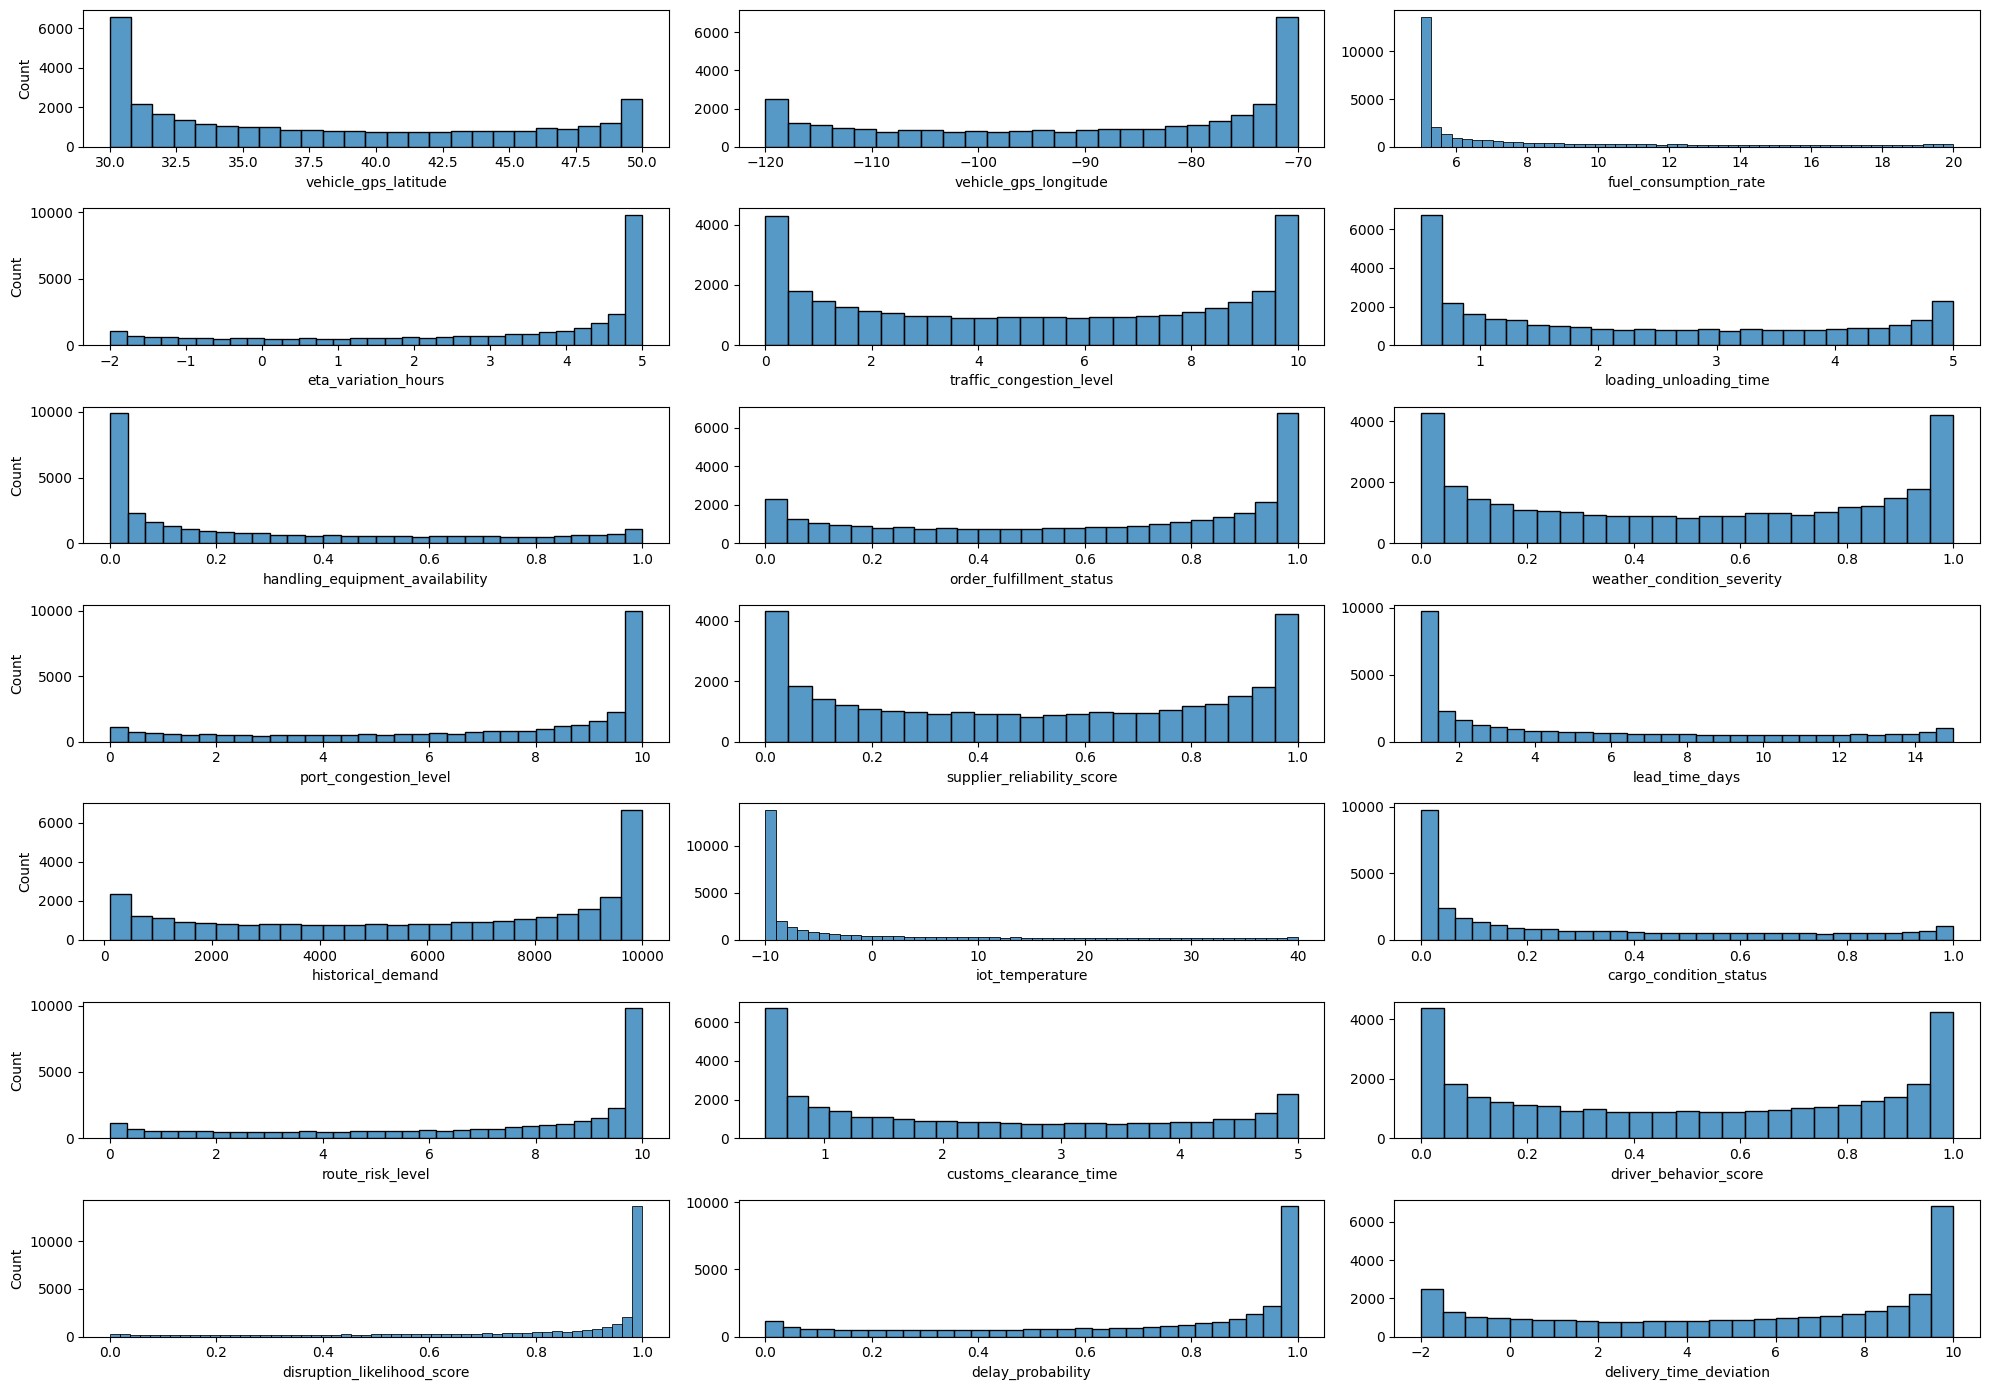

In [13]:
fig, axis = plt.subplots(7, 3, figsize=(20, 14))
sns.histplot(ax=axis[0,0], data=df, x="vehicle_gps_latitude")
sns.histplot(ax=axis[0,1], data=df, x="vehicle_gps_longitude").set(ylabel=None)
sns.histplot(ax=axis[0,2], data=df, x="fuel_consumption_rate").set(ylabel=None)
sns.histplot(ax=axis[1,0], data=df, x="eta_variation_hours")
sns.histplot(ax=axis[1,1], data=df, x="traffic_congestion_level").set(ylabel=None)
sns.histplot(ax=axis[1,2], data=df, x="loading_unloading_time").set(ylabel=None)
sns.histplot(ax=axis[2,0], data=df, x="handling_equipment_availability")
sns.histplot(ax=axis[2,1], data=df, x="order_fulfillment_status").set(ylabel=None)
sns.histplot(ax=axis[2,2], data=df, x="weather_condition_severity").set(ylabel=None)
sns.histplot(ax=axis[3,0], data=df, x="port_congestion_level")
sns.histplot(ax=axis[3,1], data=df, x="supplier_reliability_score").set(ylabel=None)
sns.histplot(ax=axis[3,2], data=df, x="lead_time_days").set(ylabel=None)
sns.histplot(ax=axis[4,0], data=df, x="historical_demand")
sns.histplot(ax=axis[4,1], data=df, x="iot_temperature").set(ylabel=None)
sns.histplot(ax=axis[4,2], data=df, x="cargo_condition_status").set(ylabel=None)
sns.histplot(ax=axis[5,0], data=df, x="route_risk_level")
sns.histplot(ax=axis[5,1], data=df, x="customs_clearance_time").set(ylabel=None)
sns.histplot(ax=axis[5,2], data=df, x="driver_behavior_score").set(ylabel=None)
sns.histplot(ax=axis[6,0], data=df, x="disruption_likelihood_score")
sns.histplot(ax=axis[6,1], data=df, x="delay_probability").set(ylabel=None)
sns.histplot(ax=axis[6,2], data=df, x="delivery_time_deviation").set(ylabel=None)

plt.tight_layout()

### Observaciones:
> - `fuel_consumption_rate`: Presenta una distribucion unimodal con sesgo positivo, la moda se situa en el valor 5, seguida de un decrecimiento exponencial de la frecuencia a medida que augmenta el consumo. Se observan ligeros repuntes cerca de los valores 12 y 20 que sugiere comportamiento atipicos o condiciones de operaciones específicas

> - `eta_variation_hours`: Presenta una distribucion unimodal de sesgo negativo la moda se situa en el  valor 5. La distribución presenta un crecimiento exponencial a medida que augmentan las horas de retraso, sin embargo hay un salto abrupto al llegar al valor 5, indica un proceso de censura de los registros a la derecha 'capping'. Hay un leve repunte en el valor -2 que indica llegadas anticipadas mientras que los positivos representan retrasos.

> - `traffic_congestion_level`: Presenta una distribución bimodal simetrica en forma de "U", con picos en los valores extremos 0 y 10. La mayoria de casos se concentran en el valor 0, escenarios de flujo libre o en el valor 10 donde la congestion del trafico fue máxima. El valle que se observa, cerca del valor central (5) es una region de baja densidad, indinca que el estado intermedio de trafico es menos frecuente que el estado de fluidez o saturación.
 
> - 'loading_unloading_time' La carga y descarga de los paquetes suele estar entre (0 - 1) debido a entregas rápidas de paquetes fáciles de maniobrar o con lugares de entrega de fácil acceso.
> - 'handling_equipment_availability' El estado de la disponibilidad de equipos como montacargas, suele ser nula.
> - 'order_fulfillment_status' El estado que indica si el pedido se ha cumplido a tiempo parece ser positivo alrededor del 75% de las veces.
> - 'weather_condition_severity' La gravedad de las condiciones meteorológicas está sesgada en situaciones sin complicaciones (0) a situaciones complejas (1).
> - 'port_congestion_level' La congestión del puerto se sitúa con un valor de 10, más del 75% de las ocasiones se encuentra saturado o hay una gran congestión, por lo que dificulta sus accesos.
> - 'supplier_reliability_score' La confianza del proveedor está sesgada en aquellos en los que su confianza ha disminuido a (0) como en aquellos que mantienen su fiabilidad con una excelente puntuación de (1).
> - 'lead_time_days' El tiempo promedio con diferencia en en que un proveedor entrega materiales suele ser desde el primer al segundo día, con más de un 75% de entregas realizadas en esa franja.
> - 'historical_demand' La demanda historica de servicios logisticos tien un promedio que ronda las 10000 unidades
> - 'iot_temperature' La temperature de iot_suele suele marcar por debajo de los -10º
> - 'cargo_condition_status' El estado de la carga según la monitorización del iot teien picos de carga no optima pero a la vez tambien tiene picoz que sugiere que muchas ocasiones la carga se encuentra en estado optimo.
> - 'route_risk_level' El nivel de riesgo asociado a una determinada ruta es en general muy elevado, muestra un pico en la maximá puntuación.
> - 'customs_clearance_time' El tiempo necesario con el que pasa los envios por aduanas por lo general no suele durar mas de 1 día.
> - `driver_behavior_score`: La variable presenta una distribución bimodal con picos en 0 y 1, sugiere que la puntuación del conductor se concentra en dos grupos opuestos , el desempeño excelente y deficiente. Presenta baja densidad en los valores intermedios, confirma que el perfil del conductor promedio no es representativo.
> - 'disruption_likelihood_score' La probabilidad de que se produzca una interrupción, es muy alta, más del 75% de las veces.
> - 'delay_probability' La probabilidad de que un envio se retrase es muy alta.
> - 'delivery_time_deviation' La desviación en horas respecto al tiempo de entrega previsto, suele ser de 10 o mas horas.